<a href="https://colab.research.google.com/github/KatherinneOlaya/Ormuz-XGBoosting/blob/main/ORMUZ_Creaci%C3%B3n_de_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np

In [2]:
# 1. Vamos a utilizar dt para leer los datos del estrecho de Ormuz que está subido al drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dt = pd.read_csv("/content/drive/MyDrive/Estrecho de Ormuz/dataset_ormuz_45dias.csv")

# 1. Data Ingestion y EDA
**Data Ingestion**: Aquí usualmente se centraliza la informació del mundo real. A parte de este caso, usualmente están los datos regados conectando con ERPs, WMS, APIs externas y generando merging.
---> En este caso solo usamos un csv

**EDA (Exploratory Data Analysis: *Control de calidad*)**: Aquí vemos que los datos sean buenos, tengan salud para la información.
1. Missing Values: Para imputación o eliminación
2. Outliers
3. Matriz de correlación

In [4]:
# 2. Vamos a hacer Data Ingestion y EDA
dt

,date,brent_price,vol_exp_ksa,flete_index,congestion_ormuz,volatilidad
0,2026-03-16 22:32:51.319076,84.88,7.20,125.7,10,1.30
1,2026-03-17 22:32:51.319076,85.66,7.16,121.7,10,1.45
2,2026-03-18 22:32:51.319076,85.23,7.22,121.1,11,1.86
3,2026-03-19 22:32:51.319076,85.89,7.13,122.0,8,1.81
4,2026-03-20 22:32:51.319076,84.46,7.05,125.3,11,1.46
5,2026-03-21 22:32:51.319076,83.39,7.10,119.0,10,1.49
6,2026-03-22 22:32:51.319076,84.33,7.12,117.5,10,1.11
7,2026-03-23 22:32:51.319076,85.61,7.21,119.2,12,1.20
8,2026-03-24 22:32:51.319076,83.49,7.39,123.0,12,1.38
9,2026-03-25 22:32:51.319076,82.85,7.00,127.0,13,1.44


In [5]:
dt.describe().T

,count,mean,std,min,25%,50%,75%,max
brent_price,45.0,87.424667,3.355977,82.24,85.27,86.45,89.17,97.87
vol_exp_ksa,45.0,6.521778,0.601926,5.42,6.05,6.44,7.13,7.39
flete_index,45.0,152.231111,23.645015,117.50,125.30,160.20,171.10,186.70
congestion_ormuz,45.0,26.400000,13.977905,8.00,12.00,29.00,39.00,47.00
volatilidad,45.0,2.503778,1.111850,1.11,1.49,2.37,2.95,5.41


No hay datos nulos por counting. Utilizamos el 50%, *mediana* o *Q2*

In [6]:
# --> Vamos a verificar que efectivamente no tuvimos nulos como se dijó anteriormente

dt.isnull().sum()

,0
date,0
brent_price,0
vol_exp_ksa,0
flete_index,0
congestion_ormuz,0
volatilidad,0


In [7]:
## ---> Verificamos que no hayan datos duplicados, como tomados 2 veces el mismo día y registrados así

dt[dt.duplicated]

,date,brent_price,vol_exp_ksa,flete_index,congestion_ormuz,volatilidad


In [8]:
'''
-------------------------------------------------------------------
REALIZAMOS ANALISIS UNIVARIADO Y BIVARIADO
------------------------------------------------------------------
'''

'\n-------------------------------------------------------------------\nREALIZAMOS ANALISIS UNIVARIADO Y BIVARIADO\n------------------------------------------------------------------\n'

In [9]:
# Univariado

## En este dataset ya sabemos que todas son variables numericas, pero dejo el código
## para cuando tengas que ver cuantas hay de cada tipo: Numerica - Categorica

tipo_data = pd.DataFrame(data = dt.dtypes, columns = ['info'])
type_columns = {}

for types in tipo_data['info']:
  if types  not in type_columns:
    type_columns[types] = 1
  else:
    type_columns[types] += 1

print(type_columns)


## Aunque aquí me hizo percatarme que la columna objeto corresponde a una serie de tiempo


{dtype('O'): 1, dtype('float64'): 4, dtype('int64'): 1}


In [10]:
dt_num= dt.select_dtypes(include = [np.number])
dt_num.columns

Index(['brent_price', 'vol_exp_ksa', 'flete_index', 'congestion_ormuz',
       'volatilidad'],
      dtype='object')

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt



 brent_price 



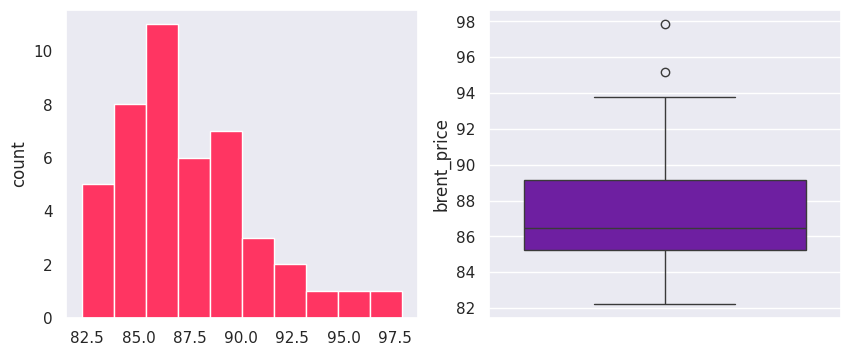


 vol_exp_ksa 



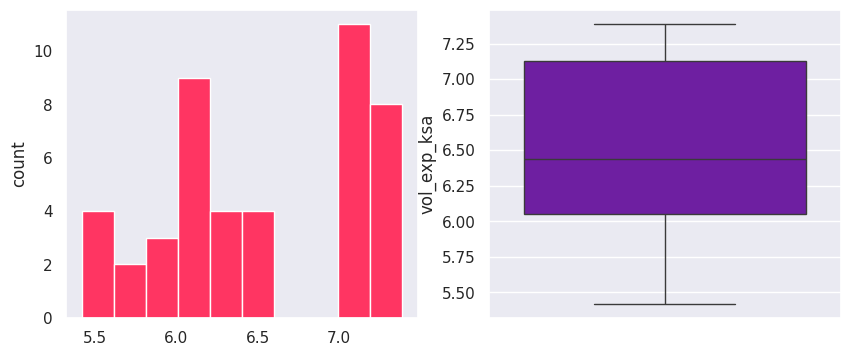


 flete_index 



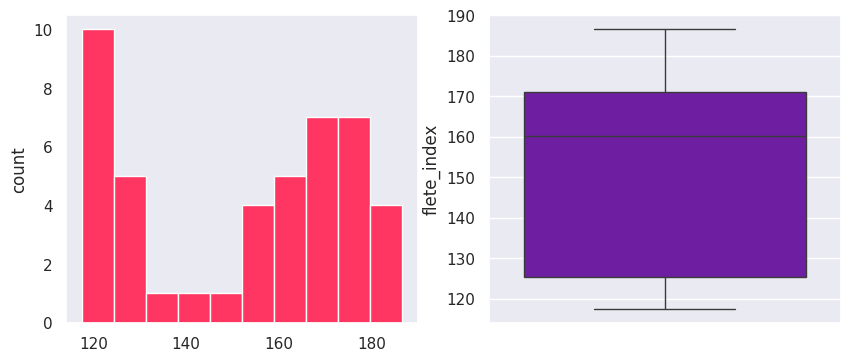


 congestion_ormuz 



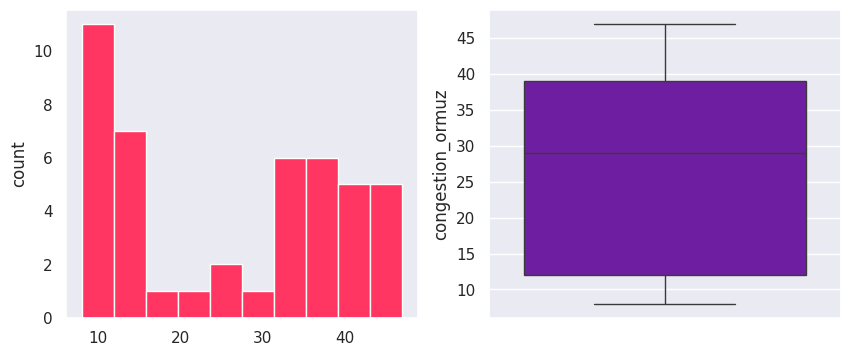


 volatilidad 



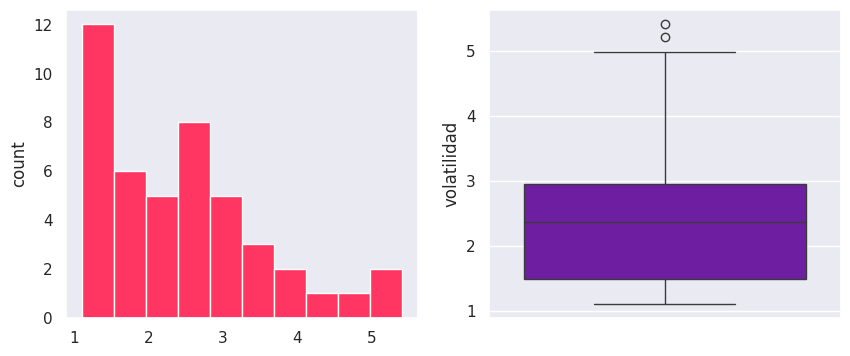

In [12]:
### Plotting Numerical data
for i in dt_num.columns:
  sns.set(style = 'darkgrid')
  print('\n', i, '\n')
  plt.figure(figsize = (10,4))
  plt.subplot(1,2,1)
  dt_num[i].hist(bins=10, grid=False, color = '#ff3562')
  plt.ylabel('count')
  plt.subplot(1,2,2)
  sns.boxplot(dt_num[i], color = '#7209b7')
  plt.show()


In [13]:
print(len(dt_num.columns))

5



 brent_price 



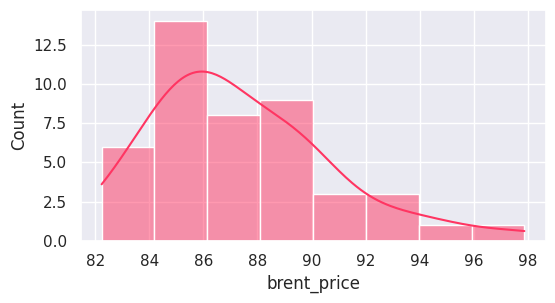


 vol_exp_ksa 



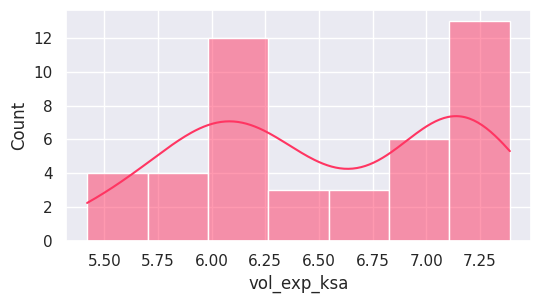


 flete_index 



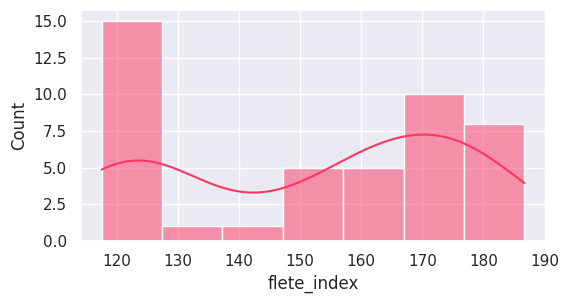


 congestion_ormuz 



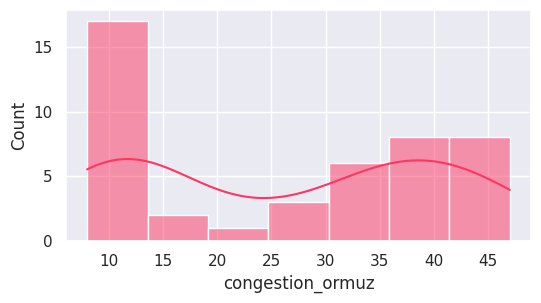


 volatilidad 



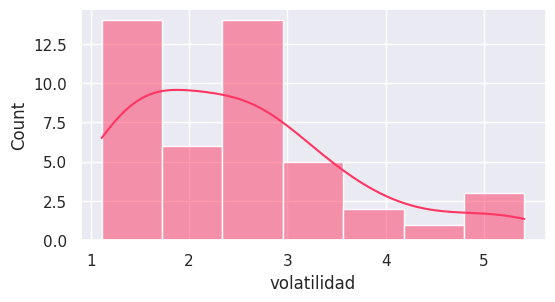

In [14]:

for i in dt_num.columns: # Plor histogram to find patterns
  sns.set(style = 'darkgrid')
  print('\n', i, '\n')
  plt.figure(figsize = (6,3))
  plt.subplot(1,1,1)
  sns.histplot(data = dt_num, x = i, kde= True, color = '#ff3562')
  plt.show()

**ANALISIS**:
El histograma muestra el conteo de los valores con mayor repetición, el boxplot nos dice que dentro del rango de 25%-75% la operación es nomal. Los bigotes hablan de los minimos y máximos. Por otro lado los outliers nos advierte cuando se rompió el mercado



## 📊 Análisis Ejecutivo de Histogramas: Radiografía de la Crisis

* 🛢️ **Precio del Brent (`brent_price`) ➔ *Sesgo Positivo***
* **La Realidad:** La mayor parte del mes el precio se mantiene cómodo y predecible (entre **$85 y $87**).
* **El Riesgo:** Presenta una "cola larga" hacia la derecha. Esto significa que el riesgo financiero no es simétrico: cuando hay pánico, el precio no sube un poco, **se dispara hacia los $98**.


* 🚢 **Volumen de Exportación (`vol_exp_ksa`) ➔ *Bimodal (Dos Jorobas)***
* **La Realidad:** Funciona como un interruptor de encendido y apagado. No hay puntos medios.
* **El Riesgo:** O el estrecho está libre y exportas a máxima capacidad (**7.2M barriles**), o está bloqueado y el flujo se estrangula de golpe (**6.1M barriles**).


* 💸 **Índice de Flete (`flete_index`) ➔ *Bimodal (Dos Jorobas)***
* **La Realidad:** Refleja dos dimensiones de costos completamente separadas.
* **El Riesgo:** La mitad del tiempo pagaste tarifas de paz baratas (**120**), y la otra mitad pagaste primas por riesgo de guerra altísimas (**170**). *Nota gerencial: Planear con el "promedio" aquí te llevaría a la quiebra.*


* ⚓ **Congestión (`congestion_ormuz`) ➔ *Bimodal (Dos Jorobas)***
* **La Realidad:** Es el origen físico del problema logístico (Teoría de Colas).
* **El Riesgo:** O los barcos transitan sin detenerse (**< 15 buques**), o el sistema de paso se rompe por completo creando un mega estacionamiento flotante (**> 35 buques**).


* ⚡ **Volatilidad (`volatilidad`) ➔ *Sesgo Positivo con Pico Extremo***
* **La Realidad:** Es tu **"indicador temprano"**. La mayor parte del tiempo el miedo del mercado es bajo y manejable.
* **El Riesgo:** Ante un rumor de bloqueo, el miedo salta repentinamente a su nivel máximo (**5.4**). Como el pánico viaja más rápido que los barcos, esta variable le avisará a tu modelo de Inteligencia Artificial que el caos físico está por llegar.



---

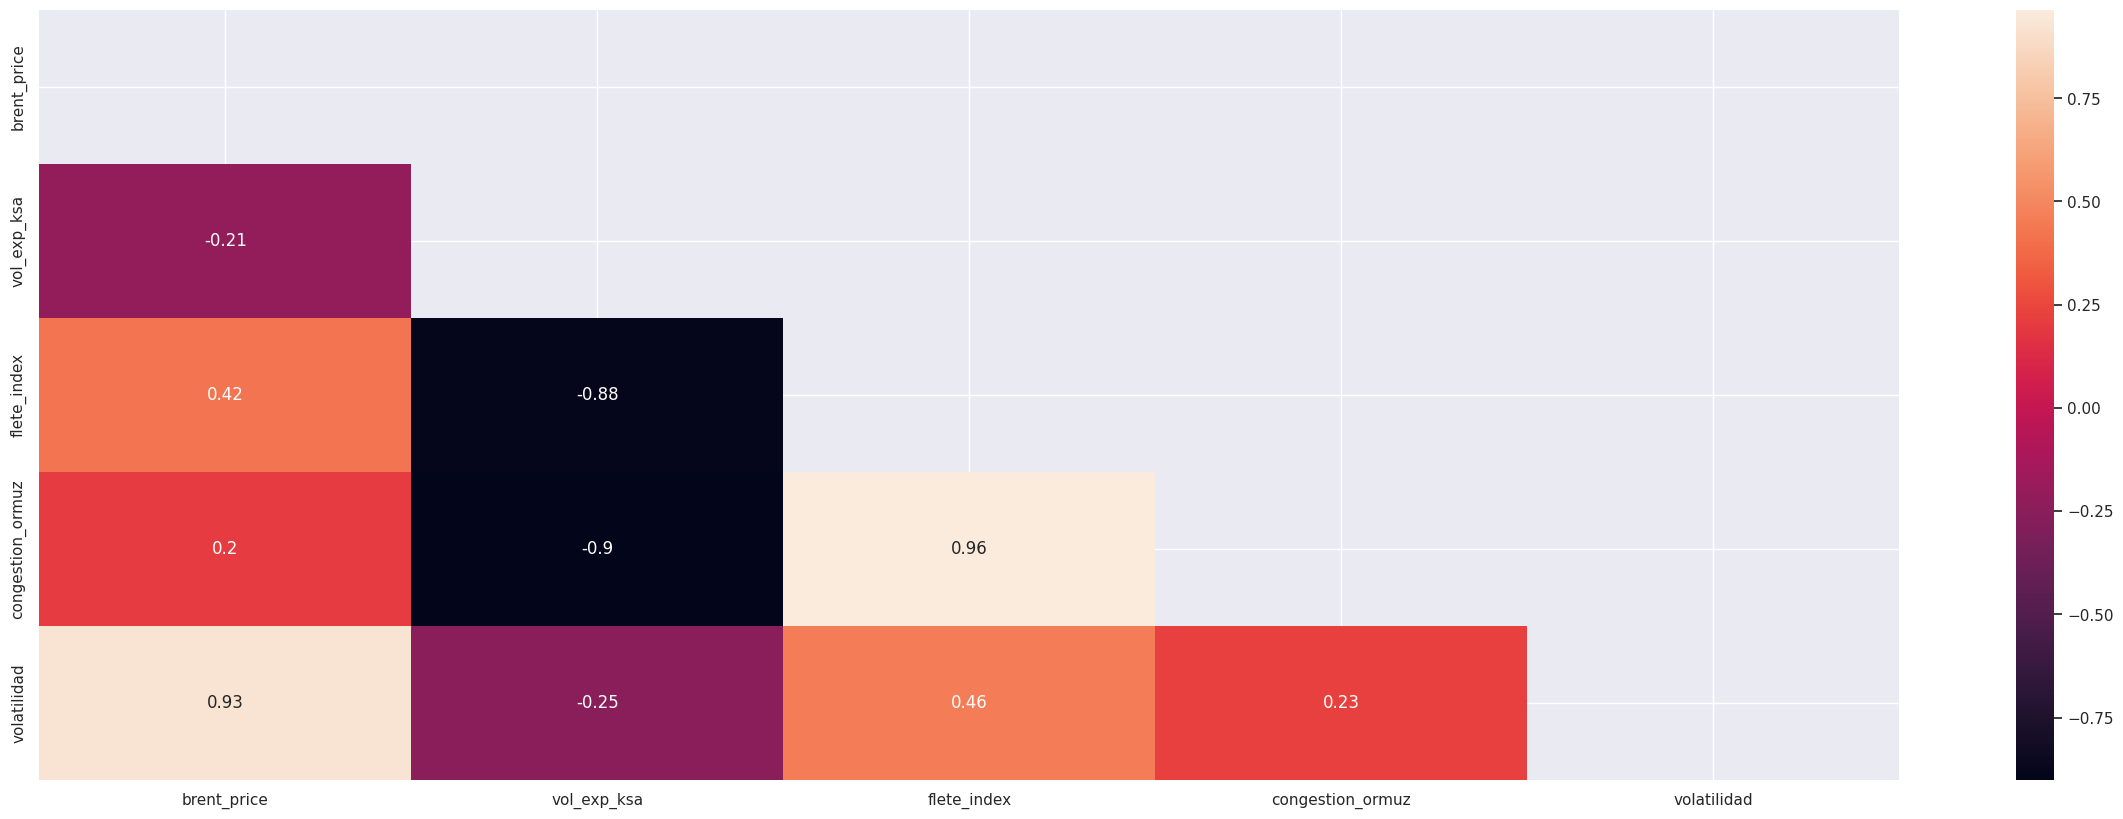

In [15]:
''' ------------------ Matriz de Correlación ------------------------- '''
# La matriz de correlación revela cómo y cuáles variables interactúan entre sí
# Permite el feature selection, en este caso como vamos a usar XGBoost, necesitamos variables que sean diferentes a 0 para no dar ruido
# Evitamos multicolinealidad: Borramos data con info +1 porque dicta lo mismo
mask = np.triu(np.ones_like(dt_num.corr()))
# Plot our correlation matrix, only up triangle, for not repeat data beacuse it's symetric
sns.set(style ='darkgrid')
plt.figure(figsize = (30,10))
sns.heatmap(dt_num.corr(),  annot= True, mask = mask);

1. Es bastante interesante analizar que el precio del petroleo crudo se relaciona directamente al miedo o pánico en wall Street y no necesariamente al atasco físico

# Feature Engineering: *Data preprocessing*
En este temario analizamos algo bastante interesante, y es que el modelo XGBoost no comprene el tiempo. Es por tanto que es necesario que entienda el pasado para convertirlo en una serie temporal de variables con ifnormación del pasado.

In [16]:
# 1. Limpieza y preparación de fechas.

## Analizamos de qué tipo es df[date]
print(dt['date'].dtypes)

object


In [17]:

## Hacemos una copia por si dañamos el conjunto original
df = dt.copy()

In [18]:
## Pasamos a fecha:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')


In [19]:
df = df.reset_index(drop=True)

In [20]:
## 2. Creación de variables rezagas o lags para darle memoria al modelo.

for lag in [1,2,3,7]:
  df[f'brent_lag{lag}'] = df['brent_price'].shift(lag)

## ---> Esto da el precio de ayer, de hace dos días, tres y una semana

In [21]:
## 3. Cración de estadísticas móviles.

df['brent_ma_3'] = df['brent_price'].rolling(3).mean() # --> Tendencia últims 3 días
df['brent_ma_7'] = df['brent_price'].rolling(7).mean() # --> Tendencia últims 7 días
df['brent_std_7'] = df['brent_price'].rolling(7).std() # --> Volatilidad en la semana


In [22]:
## 4. Variables exógenas de lags
for lag in [1, 3]:
    df[f'flete_lag_{lag}'] = df['flete_index'].shift(lag)
    df[f'ormuz_lag_{lag}'] = df['congestion_ormuz'].shift(lag)
    df[f'ksa_lag_{lag}'] = df['vol_exp_ksa'].shift(lag)

In [23]:
## 5. Variables de cambio (%)
df['brent_return'] = df['brent_price'].pct_change()
df['flete_change'] = df['flete_index'].pct_change()

In [24]:
## 6. Variable estacionalidad: Calendario
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

In [39]:
df['target'] = df['brent_price'].shift(-1) # ---> Vemos hacia el futuro


In [40]:
## 7. Eliminar NaN creado por shift o rolling
df = df.dropna(subset=['target']) # ---> Borramos la fila 1

In [41]:
## 8. SEPARACIÓN DE X y de Y
#### y -> Va a ser cuánto va a valer el crudo mañana


x = df.drop(['date', 'brent_price', 'target'], axis = 1, errors = 'ignore')
y = df['target']


### Train and testing: Modeling
1. En train y testing, vamos a cortar los datos directamente al 80% para sacar los del 205 sin combinar pasado con futuro.

In [42]:
split = int(len(df)*0.8)
X_train = x[:split]
X_test = x[split:]

y_train = y[:split]
y_test = y[split:]



$$y_{t+1}=f(y_t,y_{t-1},x_t)$$

Modelo que analiza el precio del crudo mañana, con variables de precio del crudo de hoy, y ayer; junto con variables exógenas y las medias móviles calculadas antes

In [28]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('-'*100)
print('\n ✨ XGBoosting Modelado ✨\n')
print('-'*100)
print('-'*100)
print('-'*100)

----------------------------------------------------------------------------------------------------

 ✨ XGBoosting Modelado ✨

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------


In [29]:
modelo_xgb = XGBRegressor(
    n_estimators = 100,
    max_depth = 4,
    learning_rate = 0.05,
    objective = 'reg:squarederror',
    random_state =42
)

print('-'*100)
print('\n ✨ XGBoosting Entrenamiento de datos historicos... ✨\n')
print('-'*100)
print('-'*100)
modelo_xgb.fit(X_train, y_train)

----------------------------------------------------------------------------------------------------

 ✨ XGBoosting Entrenamiento de datos historicos... ✨

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [32]:
## ------- Predicciones -------- ##

prediccion = modelo_xgb.predict(X_test)



In [45]:
## ---------- Evaluación del negocio ------- ##
'''
Aqui vamos a reocrdar que queremos hallar el precio del crudo para mañana
por eso al usar la metrica de MAE, sacamos el valor preciso de cuanto se equivoca
el modelo en métrica de dolares ---> MAE es el promedio simple

2. RMSE: Aqui penalizamos los errores grandes para poder ver que el modelo
no haga simplemente un promedio y ya está sino que analicemos que concuerde


=================================================================================
Si logramos que RMSE y MAE sean iguales significa que el modelo trabaja bien incluso
cuando solo nos está mostrando un promedio


3. R^2: Añadimos esto para anlizar qué porcentaje logramos domar el modelo.
Qué tan controlada tenemos la situación
'''

mae = mean_absolute_error(y_test, prediccion)
rmse = np.sqrt(mean_squared_error(y_test, prediccion))
r2 = r2_score(y_test, prediccion)

In [50]:
print("🗨️🗨️🗨️ Primer intento ")

print("\n" + "="*40)
print("REPORTE DE RENDIMIENTO (AUDITORÍA CFO)")
print("="*40)
print("="*40)
print("="*40)
print("\n\n")

print(f"1. MAE (Margen de error absoluto): ${mae:.2f}")
print(f"2. RMSE (Penalización por errores grandes): ${rmse:.2f}")
print(f"3. R2 (Nivel de confianza del modelo): {r2*100:.1f}%")
print("="*40)

🗨️🗨️🗨️ Primer intento 

REPORTE DE RENDIMIENTO (AUDITORÍA CFO)



1. MAE (Margen de error absoluto): $1.99
2. RMSE (Penalización por errores grandes): $2.37
3. R2 (Nivel de confianza del modelo): -309.0%


### Primer intento:
El modelo avisa que el MAE y RMSE, hay un margen de error bastante bajo, para la junta directiva supone que el modelo predijo en los mejores días se equivoca cerca de dos dolares, y en los peores 2,37.

El R^2 avisa que el modelo predictivo lo hizo muy mal. Pero para eso volvemos a hacer los hiperparametros para que no sea tan complejo sino más sencillo. -----> **Regularización**




```
modelo_xgb = XGBRegressor(

    n_estimators = 100,

    max_depth = 4,

    learning_rate = 0.05,

    objective = 'reg:squarederror',

    random_state =42

)
```



In [51]:
modelo_xgb_1 = XGBRegressor(
    n_estimators = 30,
    max_depth = 2,
    learning_rate = 0.1, # Menos árboles + aprendizaje
    reg_lambda = 5, # Penalización si da números muy grandes
    objective = 'reg:squarederror',
    min_child_weight = 3, #Obligamos al modelo que aplique las reglas a 3 ! días
    random_state =42
)
modelo_xgb_1.fit(X_train, y_train)
prediccione_1 = modelo_xgb_1.predict(X_test)

mae_1 = mean_absolute_error(y_test, prediccione_1)
rmse_1 = np.sqrt(mean_squared_error(y_test, prediccione_1))
r2_1 = r2_score(y_test, prediccione_1)

print("🗨️🗨️🗨️ Primer intento ")

print("\n" + "="*40)
print("REPORTE DE RENDIMIENTO (AUDITORÍA CFO)")
print("="*40)
print("="*40)
print("="*40)
print("\n\n")

print(f"1. MAE (Margen de error absoluto): ${mae_1:.2f}")
print(f"2. RMSE (Penalización por errores grandes): ${rmse_1:.2f}")
print(f"3. R2 (Nivel de confianza del modelo): {r2_1*100:.1f}%")
print("="*40)


🗨️🗨️🗨️ Primer intento 

REPORTE DE RENDIMIENTO (AUDITORÍA CFO)



1. MAE (Margen de error absoluto): $1.62
2. RMSE (Penalización por errores grandes): $1.86
3. R2 (Nivel de confianza del modelo): -151.8%


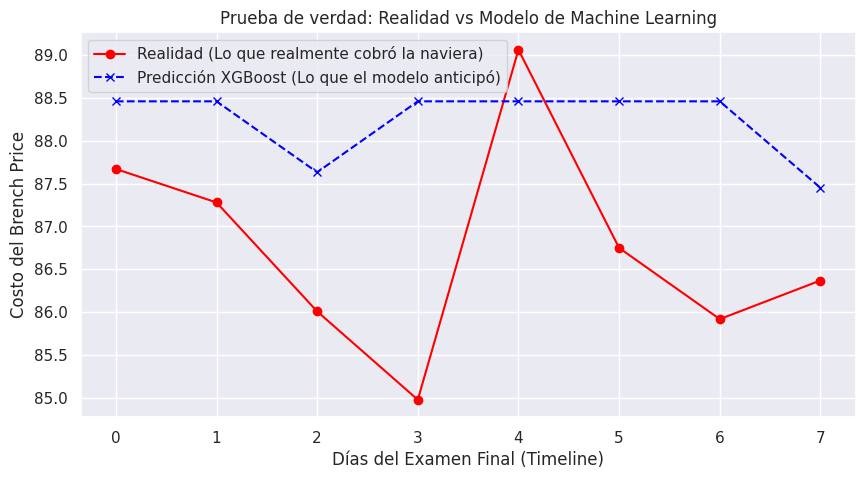

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Realidad (Lo que realmente cobró la naviera)', color='red', marker='o')
plt.plot(prediccione_1, label='Predicción XGBoost (Lo que el modelo anticipó)', color='blue', linestyle='--', marker='x')
plt.title('Prueba de verdad: Realidad vs Modelo de Machine Learning')
plt.ylabel('Costo del Brench Price')
plt.xlabel('Días del Examen Final (Timeline)')
plt.legend()
plt.grid(True)
plt.show()

### Modelo 2:
El modelo mejoro el MAE y RMSE, pero sigue teniendo dificultades cobn R^2, que se debe principalmente a que es un modelo con pocos datos. La gráfica demuestra que está muy controlado y no se está atreviendo a predecir crisis, vamos a cambiar parametros para el otro modelo

In [61]:
modelo_xgb_2 = XGBRegressor(
    n_estimators = 50,
    max_depth = 3,
    learning_rate = 0.1, # Menos árboles + aprendizaje
    reg_lambda = 1, # Penalización si da números muy grandes
    objective = 'reg:squarederror',
    min_child_weight = 1, #Obligamos al modelo que aplique las reglas a 3 ! días
    random_state =42
)
modelo_xgb_2.fit(X_train, y_train)
prediccione_2 = modelo_xgb_2.predict(X_test)

mae_2 = mean_absolute_error(y_test, prediccione_2)
rmse_2 = np.sqrt(mean_squared_error(y_test, prediccione_2))
r2_2 = r2_score(y_test, prediccione_2)

print("🗨️🗨️🗨️ Tercer intento ")

print("\n" + "="*40)
print("REPORTE DE RENDIMIENTO (AUDITORÍA CFO)")
print("="*40)
print("="*40)
print("="*40)
print("\n\n")

print(f"1. MAE (Margen de error absoluto): ${mae_2:.2f}")
print(f"2. RMSE (Penalización por errores grandes): ${rmse_2:.2f}")
print(f"3. R2 (Nivel de confianza del modelo): {r2_2*100:.1f}%")
print("="*40)


🗨️🗨️🗨️ Tercer intento 

REPORTE DE RENDIMIENTO (AUDITORÍA CFO)



1. MAE (Margen de error absoluto): $0.92
2. RMSE (Penalización por errores grandes): $1.07
3. R2 (Nivel de confianza del modelo): 16.0%


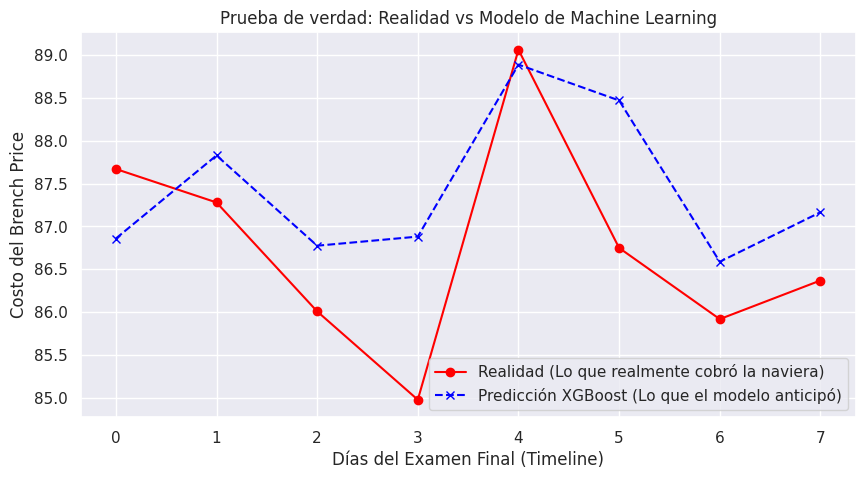

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Realidad (Lo que realmente cobró la naviera)', color='red', marker='o')
plt.plot(prediccione_2, label='Predicción XGBoost (Lo que el modelo anticipó)', color='blue', linestyle='--', marker='x')
plt.title('Prueba de verdad: Realidad vs Modelo de Machine Learning')
plt.ylabel('Costo del Brench Price')
plt.xlabel('Días del Examen Final (Timeline)')
plt.legend()
plt.grid(True)
plt.show()

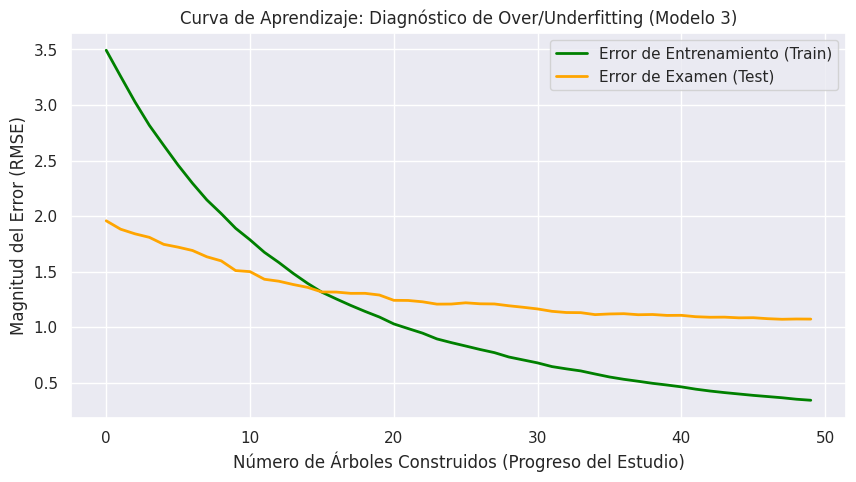

In [63]:
''' Hacemos curva de aprendizaje para analizar si generó overfitting o underfitting
    o si salió como esperabamos'''
# Pasamos un 'eval_set' para que mida el error en tiempo real
evaluaciones = [(X_train, y_train), (X_test, y_test)]

modelo_xgb_2.fit(
    X_train, y_train,
    eval_set=evaluaciones,
    verbose=False # Para no llenadr de texto innecesario
)

# 3. Extraemos el historial de errores (RMSE) de cada árbol construido
resultados = modelo_xgb_2.evals_result()
error_train = resultados['validation_0']['rmse']
error_test = resultados['validation_1']['rmse']

# 4. Graficamos las dos curvas
plt.figure(figsize=(10, 5))
plt.plot(error_train, label='Error de Entrenamiento (Train)', color='green', linewidth=2)
plt.plot(error_test, label='Error de Examen (Test)', color='orange', linewidth=2)

plt.title('Curva de Aprendizaje: Diagnóstico de Over/Underfitting (Modelo 3)')
plt.xlabel('Número de Árboles Construidos (Progreso del Estudio)')
plt.ylabel('Magnitud del Error (RMSE)')
plt.legend()
plt.grid(True)
plt.show()

### Resultados:
El modelo presenta, un error en entrenamiento bastante alto y baja de manera suave hasta aprox 0,35. Demostrando que el modelo tiene la capacidad matemática de entender las variables y aprender patrones historicos de crisis. La línea naranja demuestra que el modelo se estabilizó y no generó overfitting porque no empezó a subir (a empezar a aprender todo, incluso el ruido)
 - La intersección demuesta que el dataset de train tenía mucha volatilidad, y test logró atinarle mientras estabilizaba el dataset de train a medida del tiempo
 - La brechas se estabilizó. No esta una subiendo y otra bajando (overfitting) ni las dos pegadas o muy separadas (underfitting). Estan en una distancia buena

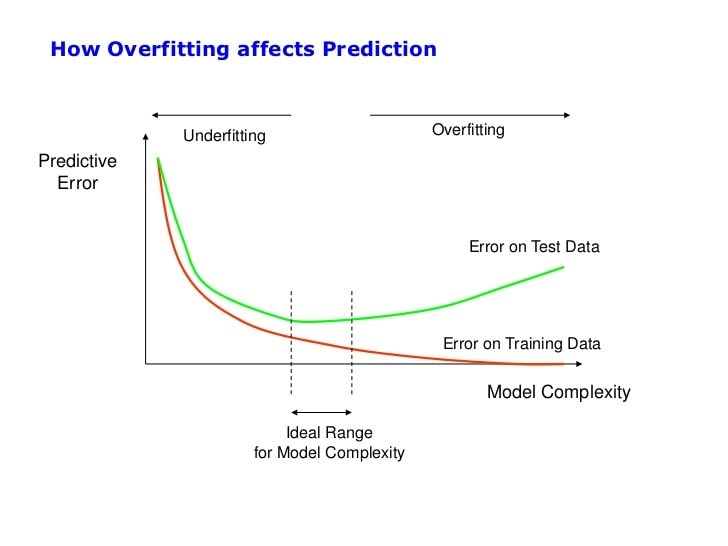

# Gráfica Cruva de Aprendizaje:
 ### Underfitting:
 En una gráfica así, el error de entrenamiento y de test son bastante alto. Las curvas quedan cercanas y se estabilizan arriba. Aquí no logra aprender nada

 ### Overfitting:
 Train sigue bajando mucho, test baja al principio pero luego sube. En ese punto se puede observar que empieza a memorizar ruido

 ### Buen balance:
 Ambas curvas bajan, se estabilizan. Tienen separación entre ellas de forma moderada. Test alcanza un mínimo estable. Train bajo + test bajo y estable

# 🧾👩🏻‍💼 Interpretabilidad 🧾👩🏻‍💼

Ya se logró el modelo, ahora explicamos porqué funciona el modelo.
Aqui trabajamos con *Feature importance* explicando cuantas veces el algoritmo usó cada columna para partir los datos y reducir el error, y qué tan determinante fue todo para dictar el precio del petroleo crudo.

/tmp/ipykernel_23218/3739085399.py:30: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


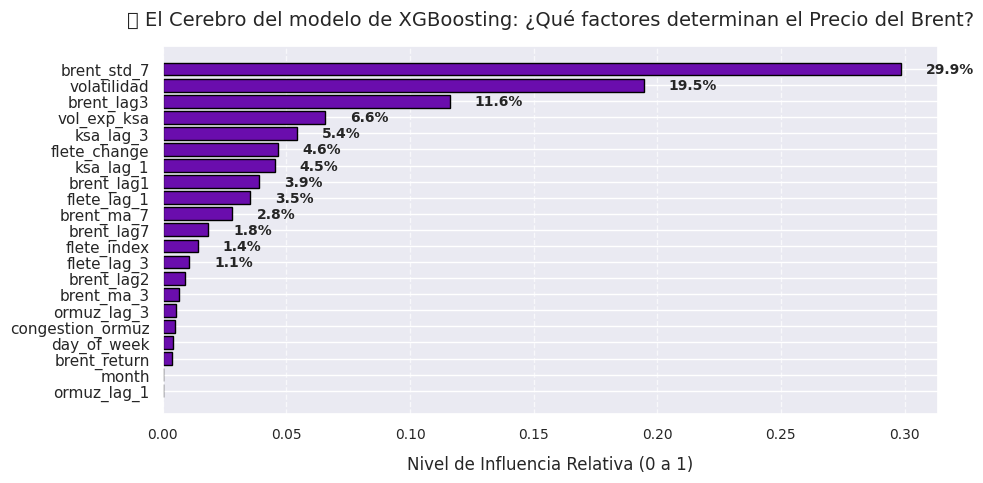

In [68]:
# 1. Extraer las importancias del Modelo 3 que ya entrenamos
importancias = modelo_xgb_2.feature_importances_
variables = X_train.columns


# 2. Ordenar los índices de menor a mayor importancia para que la barra más larga quede arriba
indices_ordenados = np.argsort(importancias)

# 3. Diseñar la gráfica para la presentación de negocios
plt.figure(figsize=(10, 5))
plt.barh(
    range(len(indices_ordenados)),
    importancias[indices_ordenados],
    color='#6a0dad',
    edgecolor='black'
)

plt.yticks(range(len(indices_ordenados)), [variables[i] for i in indices_ordenados], fontsize=11)
plt.xticks(fontsize=10)

plt.title('🔬 El Cerebro del modelo de XGBoosting: ¿Qué factores determinan el Precio del Brent?', fontsize=14, pad=15)
plt.xlabel('Nivel de Influencia Relativa (0 a 1)', fontsize=12, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir los valores numéricos exactos al final de cada barra para máxima claridad
for i, v in enumerate(importancias[indices_ordenados]):
    if v > 0.01: # Solo mostrar si tiene un peso relevante
        plt.text(v + 0.01, i, f'{v*100:.1f}%', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

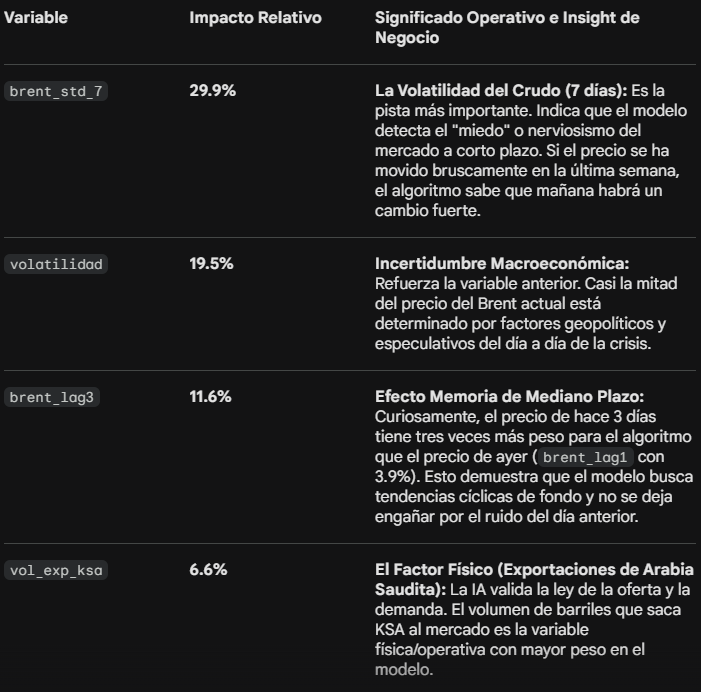

Este modelo es altamente sensible al riesgo geopolítico (**brent_std_7 + volatilidad = 49.4%**) y a los movimientos de suministro de nuestro principal competidor/aliado (v**ol_exp_ksa = 6.6%**). Al basar sus decisiones en estos pilares, el margen de error de $1.01 USD obtenido en las pruebas de fuego es completamente lógico, seguro y con bases fundamentales sólidas para planificar nuestras estrategias de inventario diario."

# 🗨️​🌐​ Despligue (Serialización y Guardado de Modelo)🗨️​🌐​

Aquí vamos a mandar el modelo al mundo real

In [70]:
import joblib
from google.colab import files

In [72]:
# 1. Guardamos el modelo entrenado
nombre_modelo = 'modelo_brent_xgb_v3.joblib'
joblib.dump(modelo_xgb_2, nombre_modelo)

# 2. Guardamos las listas de variables, para que en producción se mantengan
nombre_features = 'features_brent_v3.joblib'
joblib.dump(X_train.columns.tolist(), nombre_features)

print('-'*100)
print("Descargado exitosamente !")
print('-'*100)

files.download(nombre_modelo)
files.download(nombre_features)

----------------------------------------------------------------------------------------------------
Descargado exitosamente !
----------------------------------------------------------------------------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>